UNDERSTANDING THE PROBLEM

This problem is challenging us to build a Naive Bayes classifier to detect spam emails using the TREC 2006 public dataset. Upon dataset download, it is expected that we are able to load and clean the raw emails, tokenize, and filter the texts. Next, a dictionary must be built from the training emails and include words which are between three to twenty characters in length. TF-IDF must be used to identify important words and Naive Bayes classifier shall then be trained - and TF-IDF must again be utilized. TF-IDF results before and after Naive Bayes is implemented must be compared. Lastly, after the code implementation, recommendations must be given to explain how one can handle unseen words and discuss laplace smoothing and back-off models as potential solutions.

SOLUTION IMPLEMENTATION

The pertinent libraries in the code shall be imported:
matplotlib is for graphing plots and confusion matrices;
seaborn is for enhancing the aesthetics of the plots;
json is for saving and loading data;
sklearn is for TF-IDF, training and testing data splitting, logistic regression model training, and metrics computation.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import json
import requests
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score

The replacement path shall first be identified with the location of the given files.

In [2]:
replacement_path = r"C:\Users\Angelica Anne\Desktop\Python\AI 201\HW 2\trec06p-ai201"


We will create a function that shall define common stopwords since these are made up of linking verbs, pronouns, and prepositions which are non-informative. Thus, these can not assist in determining spam from ham emails.

In [3]:
stopwords = {
    "i", "me", "my", "myself", "we", "our", "ours", "ourselves", "you", "your",
    "yours", "yourself", "yourselves", "he", "him", "his", "himself", "she",
    "her", "hers", "herself", "it", "its", "itself", "they", "them", "their",
    "theirs", "themselves", "what", "which", "who", "whom", "this", "that",
    "these", "those", "am", "is", "are", "was", "were", "be", "been", "being",
    "have", "has", "had", "having", "do", "does", "did", "doing", "a", "an",
    "the", "and", "but", "if", "or", "because", "as", "until", "while", "of",
    "at", "by", "for", "with", "about", "against", "between", "into", "through",
    "during", "before", "after", "above", "below", "to", "from", "up", "down",
    "in", "out", "on", "off", "over", "under", "again", "further", "then",
    "once", "here", "there", "when", "where", "why", "how", "all", "any",
    "both", "each", "few", "more", "most", "other", "some", "such", "no",
    "nor", "not", "only", "own", "same", "so", "than", "too", "very", "s",
    "t", "can", "will", "just", "don", "should", "now"
}

Three consecutive duplicate letters shall be removed.

In [4]:
def remove_consecutive_duplicates(text):
    result = []
    i = 0
    while i < len(text):
        count = 1
        while i < len(text) - 1 and text[i] == text[i + 1]:
            count += 1
            i += 1
        if count < 3:
            result.extend(text[i - count + 1:i + 1])
        i += 1
    return ''.join(result)

Further, text cleaning shall be performed by removing leading and trailing spaces, converting all uppercase letters to lowercase, removing digits and non-alphanumeric characters, and retaining words which are between three to twenty characters in length.

In [5]:
def clean_text(text):
    text = text.strip().lower()  # Convert to lowercase and remove extra spaces
    cleaned_text = ''.join(char for char in text if not char.isdigit())  # Remove numbers
    cleaned_text = ''.join(char for char in cleaned_text if char.isalnum() or char.isspace())  # Keep only letters and spaces
    cleaned_text = remove_consecutive_duplicates(cleaned_text)  # Remove 3+ consecutive duplicate letters
    words = cleaned_text.split()
    filtered_words = [word for word in words if 3 <= len(word) <= 20]
    return ' '.join(filtered_words)

The cleaned texts are tokenized into individual words.

In [6]:
def tokenize(text):
    return text.split()

Stopwords shall be removed from the list of tokenized words.

In [7]:
def remove_stopwords(tokens):
    return [token for token in tokens if token not in stopwords]

Each word occurrence shall be counted and a dictionary will be returned.

In [8]:
def count_word_occurrences(tokens):
    word_count = {}
    for token in tokens:
        word_count[token] = word_count.get(token, 0) + 1
    return word_count


Spam and ham dictionaries shall store word occurences for respective spam and ham emails.

In [9]:
spam_dictionary = {}
ham_dictionary = {}

This function shall read the spam and ham labels. Moreover, it shall also read the content from the files and perform all the steps aforementioned above in a loop.

In [10]:
def build_spam_dictionary(labels_file_path, replacement_path):
    """Builds a dictionary of word occurrences for spam and ham messages."""
    with open(labels_file_path, "r") as labels:
        lines = labels.readlines()

    documents = []
    labels_list = []

    for line in lines:
        parts = line.strip().split(maxsplit=1)
        if len(parts) > 1:
            label = parts[0].lower()
            second_column = parts[1]
            full_path = second_column.replace("..", replacement_path)

            try:
                with open(full_path, 'r', encoding='utf-8', errors='ignore') as file:
                    content = file.read()
                    cleaned_content = clean_text(content)
                    tokens = tokenize(cleaned_content)
                    filtered_tokens = remove_stopwords(tokens)
                    documents.append(filtered_tokens)
                    labels_list.append(label)

                    if label == 'spam':
                        for word, count in count_word_occurrences(filtered_tokens).items():
                            spam_dictionary[word] = spam_dictionary.get(word, 0) + count
                    else:
                        for word, count in count_word_occurrences(filtered_tokens).items():
                            ham_dictionary[word] = ham_dictionary.get(word, 0) + count
            except FileNotFoundError:
                print(f"Error: The file at {full_path} does not exist.")
            except Exception as e:
                print(f"An error occurred while processing {full_path}: {e}")

    return documents, labels_list

Ham and spam dictionaries will be saved in a JSON file.

In [11]:
def save_dictionaries():
    """Saves the spam and ham dictionaries to a JSON file."""
    with open("spam_ham_dictionary.json", "w", encoding="utf-8") as f:
        json.dump({"spam": spam_dictionary, "ham": ham_dictionary}, f, indent=4)
    print("Dictionaries saved to spam_ham_dictionary.json")

Data for the test and training sets will be split into two. Eighty percent shall be alloted for training and the remaining twenty percent should be allotted for testing.

In [12]:
def split_data(documents, labels_list):
    return train_test_split(documents, labels_list, test_size=0.2, random_state=42)

compute_tfidf_scores: TF-IDF scores will be computed and shall be storing the top two hundred words with the highest scores.
train: This will be tracking the number of ham and spam messages while populating the word counts based on the TF-IDF features.
predict: This will be predicting whether a given set of tokens is ham or spam based on its training and top two hundred words.

In [13]:
class NaiveBayesWithTFIDF:
    def __init__(self):
        self.ham_word_counts = {}
        self.spam_word_counts = {}
        self.ham_count = 0
        self.spam_count = 0
        self.total_ham_words = 0
        self.total_spam_words = 0
        self.top_words = {}

    def compute_tfidf_scores(self, documents, labels):
        """Compute TF-IDF scores for words in the documents."""
        vectorizer = TfidfVectorizer()
        tfidf_matrix = vectorizer.fit_transform([' '.join(doc) for doc in documents])

        feature_names = vectorizer.get_feature_names_out()
        tfidf_scores = tfidf_matrix.sum(axis=0).A1

        word_tfidf_scores = {feature_names[i]: tfidf_scores[i] for i in range(len(feature_names))}
        self.top_words = dict(sorted(word_tfidf_scores.items(), key=lambda x: x[1], reverse=True)[:200])

        return word_tfidf_scores

    def train(self, documents, labels):
        word_tfidf_scores = self.compute_tfidf_scores(documents, labels)

        for i, tokens in enumerate(documents):
            label = labels[i]

            for word in tokens:
                if word not in self.top_words:
                    continue

                if label == 'spam':
                    self.spam_word_counts[word] = self.spam_word_counts.get(word, 0) + 1
                    self.total_spam_words += 1
                else:
                    self.ham_word_counts[word] = self.ham_word_counts.get(word, 0) + 1
                    self.total_ham_words += 1

            if label == 'spam':
                self.spam_count += 1
            else:
                self.ham_count += 1

    def predict(self, tokens):
        spam_prob = self.spam_count / (self.ham_count + self.spam_count)
        ham_prob = self.ham_count / (self.ham_count + self.spam_count)

        # to pull prior values
        self.spam_prior = spam_prob
        self.ham_prior = ham_prob

        for token in tokens:
            if token not in self.top_words:
                continue

            spam_prob *= (self.spam_word_counts.get(token, 0) + 1) / (self.total_spam_words + len(self.spam_word_counts))
            ham_prob *= (self.ham_word_counts.get(token, 0) + 1) / (self.total_ham_words + len(self.ham_word_counts))

        return 'spam' if spam_prob > ham_prob else 'ham'

This shall be loading and processing the data and splitting training and test sets.

In [14]:
# Uncomment if you want to preprocess. However, just pull preprocessed text from dropbox.

# labels_file_path = replacement_path + "\\labels"
# documents, labels_list = build_spam_dictionary(labels_file_path, replacement_path)
# documents_train, documents_test, labels_train, labels_test = split_data(documents, labels_list)

Save the needed files to json.

In [15]:
# Only run if above cell was run

# with open("documents_train.json", "w") as f:
#     json.dump(documents_train, f)

# with open("documents_test.json", "w") as f:
#     json.dump(documents_test, f)

# with open("labels_train.json", "w") as f:
#     json.dump(labels_train, f)

# with open("labels_test.json", "w") as f:
#     json.dump(labels_test, f)

# save_dictionaries()

Pull the preprocessed texts from dropbox.

In [16]:
# dropboxlinks of files
spam_ham_dictionary_link = "https://www.dropbox.com/scl/fi/bi4uwjt9q6qo2esqhfqwp/spam_ham_dictionary.json?rlkey=jxode0gr2ttu91koccp6vta4u&st=dhap4ft6&dl=1"
documents_train_link = "https://www.dropbox.com/scl/fi/gte6par0hr6rokn472jl4/documents_train.json?rlkey=rux96vmdhknw62rxl6jxy195g&st=sozu0667&dl=1"
documents_test_link = "https://www.dropbox.com/scl/fi/ry8o189i86bss934dq68i/documents_test.json?rlkey=7fk57xw51kpmvexrsp2vye9b0&st=yzyjp9vs&dl=1"
labels_train_link = "https://www.dropbox.com/scl/fi/p778plteqz7hfh4f1za73/labels_train.json?rlkey=4ty2bky3hun2nbbg6ebga8lfb&st=genvgoi8&dl=1"
labels_test_link = "https://www.dropbox.com/scl/fi/nd40w62kkq88ybmv316y9/labels_test.json?rlkey=xuhqbyq9uqb0pxu1xf1omcm5b&st=bl5qgg15&dl=1"


In [17]:
spam_ham_dictionary = requests.get(spam_ham_dictionary_link).json()
documents_train = requests.get(documents_train_link).json()
documents_test = requests.get(documents_test_link).json()
labels_train = requests.get(labels_train_link).json()
labels_test = requests.get(labels_test_link).json()

Dictionary sorted by ham

In [18]:
pd.DataFrame(spam_ham_dictionary).sort_values('ham', ascending=False)

,spam,ham
received,41768.0,49061.0
esmtp,23397.0,24770.0
subject,24375.0,21680.0
date,22972.0,19287.0
contenttype,41579.0,18272.0
...,...,...
emailyour,2.0,NaN
euroswhich,2.0,NaN
indivi,2.0,NaN
zielman,2.0,NaN


This will be initializing the Naive Bayes model and shall be computing the TF-IDF scores before and after training.

In [19]:
nb_model = NaiveBayesWithTFIDF()
word_tfidf_scores_before = nb_model.compute_tfidf_scores(documents_train, labels_train)
nb_model.train(documents_train, labels_train)
word_tfidf_scores_after = nb_model.top_words

This shall be utilizing the logistic regression model using the TF-IDF features and create predictions based on the data.

In [20]:
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform([' '.join(doc) for doc in documents_train])
X_test_tfidf = vectorizer.transform([' '.join(doc) for doc in documents_test])

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_tfidf, labels_train)

predictions_tfidf = clf.predict(X_test_tfidf)

Confusion matrices and evaluation metrics are generated for both the logistic regression and Naive Bayes.

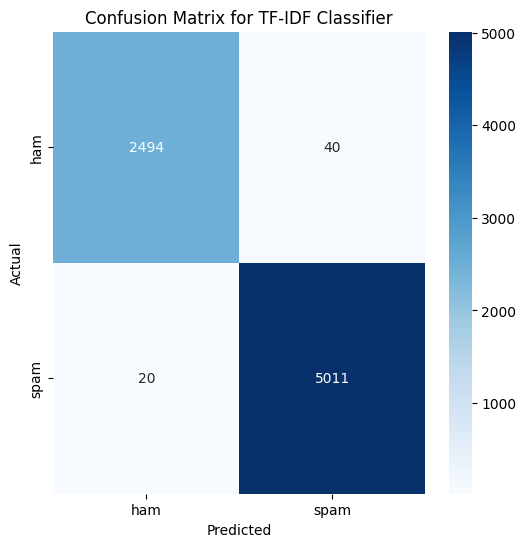

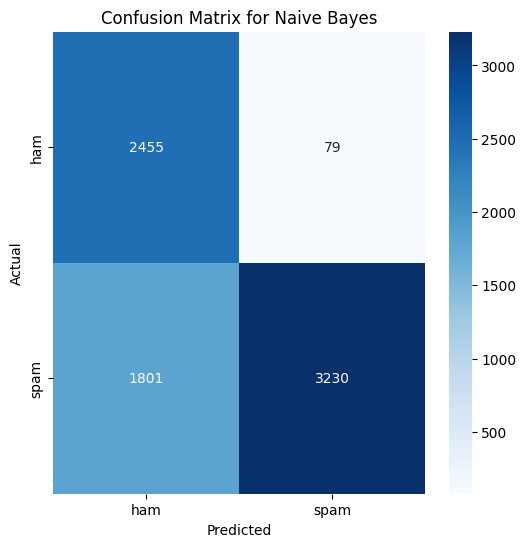

TF-IDF Logistic Regression Classifier Evaluation:
Accuracy: 99.21%
Precision: 99.21%
Recall: 99.60%
F1-score: 99.40%

Naive Bayes Classifier Evaluation:
Accuracy: 75.15%
Precision: 97.61%
Recall: 64.20%
F1-score: 77.46%


In [21]:
cm_tfidf = confusion_matrix(labels_test, predictions_tfidf)
plt.figure(figsize=(6, 6))
sns.heatmap(cm_tfidf, annot=True, fmt='d', cmap="Blues", xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
plt.title("Confusion Matrix for TF-IDF Classifier")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

predictions = [nb_model.predict(doc) for doc in documents_test]

cm_naive_bayes = confusion_matrix(labels_test, predictions)
plt.figure(figsize=(6, 6))
sns.heatmap(cm_naive_bayes, annot=True, fmt='d', cmap="Blues", xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
plt.title("Confusion Matrix for Naive Bayes")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

tfidf_accuracy = accuracy_score(labels_test, predictions_tfidf)
tfidf_precision = precision_score(labels_test, predictions_tfidf, pos_label='spam') * 100
tfidf_recall = recall_score(labels_test, predictions_tfidf, pos_label='spam') * 100
tfidf_f1 = f1_score(labels_test, predictions_tfidf, pos_label='spam') * 100

print("TF-IDF Logistic Regression Classifier Evaluation:")
print(f"Accuracy: {tfidf_accuracy * 100:.2f}%")
print(f"Precision: {tfidf_precision:.2f}%")
print(f"Recall: {tfidf_recall:.2f}%")
print(f"F1-score: {tfidf_f1:.2f}%\n")

nb_accuracy = accuracy_score(labels_test, predictions)
nb_precision = precision_score(labels_test, predictions, pos_label='spam') * 100
nb_recall = recall_score(labels_test, predictions, pos_label='spam') * 100
nb_f1 = f1_score(labels_test, predictions, pos_label='spam') * 100

print("Naive Bayes Classifier Evaluation:")
print(f"Accuracy: {nb_accuracy * 100:.2f}%")
print(f"Precision: {nb_precision:.2f}%")
print(f"Recall: {nb_recall:.2f}%")
print(f"F1-score: {nb_f1:.2f}%")

tfidf_accuracy = accuracy_score(labels_test, predictions_tfidf)
tfidf_precision = precision_score(labels_test, predictions_tfidf, pos_label='spam') * 100
tfidf_recall = recall_score(labels_test, predictions_tfidf, pos_label='spam') * 100
tfidf_f1 = f1_score(labels_test, predictions_tfidf, pos_label='spam') * 100

nb_accuracy = accuracy_score(labels_test, predictions)
nb_precision = precision_score(labels_test, predictions, pos_label='spam') * 100
nb_recall = recall_score(labels_test, predictions, pos_label='spam') * 100
nb_f1 = f1_score(labels_test, predictions, pos_label='spam') * 100

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']

logistic_regression = [tfidf_accuracy * 100, tfidf_precision, tfidf_recall, tfidf_f1]

naive_bayes = [nb_accuracy * 100, nb_precision, nb_recall, nb_f1]

Priors of the model

In [22]:
print(f'Spam prior: {nb_model.spam_prior}')
print(f'Ham prior: {nb_model.ham_prior}')

Spam prior: 0.6570710909872096
Ham prior: 0.34292890901279044


A graph is presented visually to easily compare the evaluation metrics computed.

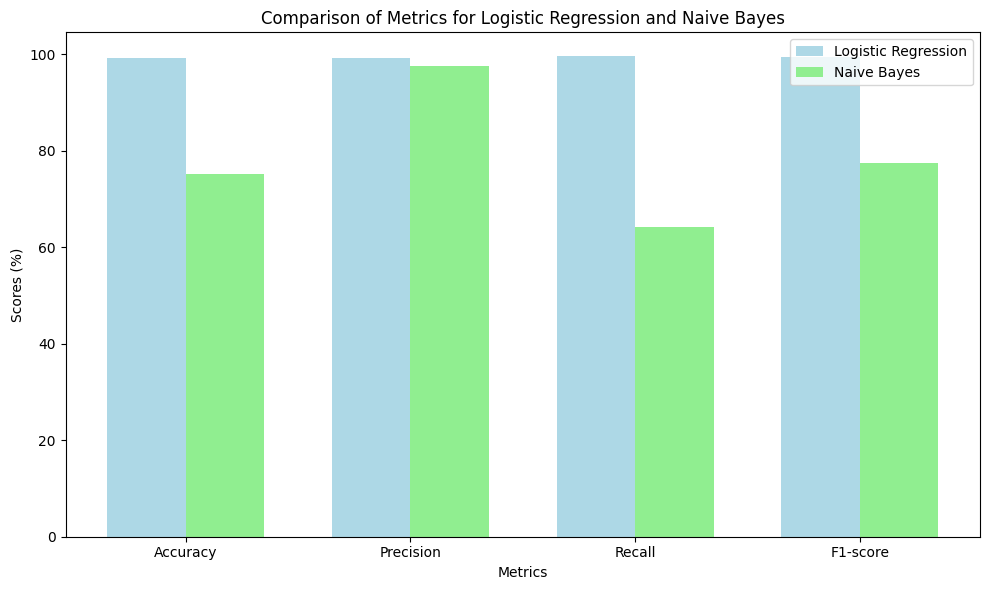

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.35
index = range(len(metrics))

ax.bar(index, logistic_regression, bar_width, label='Logistic Regression', color='lightblue')
ax.bar([i + bar_width for i in index], naive_bayes, bar_width, label='Naive Bayes', color='lightgreen')

ax.set_xlabel('Metrics')
ax.set_ylabel('Scores (%)')
ax.set_title('Comparison of Metrics for Logistic Regression and Naive Bayes')
ax.set_xticks([i + bar_width / 2 for i in index])  # Position ticks in the middle
ax.set_xticklabels(metrics)
ax.legend()

# Show the plot
plt.tight_layout()
plt.show()

RESULTS AND ANALYSIS

QUESTION: How do you determine which words are most informative?

The term frequency (TF) mesures how frequently a word appears. Its formula is given by: TF (w, d) = no. of times the word appears in a document / total number of words in the document. This formula presents that thet more word frequency equates to higher importance.

Inverse document frequency (IDF) measures how important a word is in comparison to all available documents. Its formula is given by: IDF (w)  = log(N/df(w)) where N = is the total number of documents and df(w) is the number of documents where the word appears.

TF-IDF thus presents a product that combines both the local and global importance of a word. TF-IDF(w,d) = TF(w,d) x IDF(w).

Higher TF-IDF means that a word is frequent within a document and is rare across all documents.

QUESTION: Does reducing the feature space improve or degrade performance? Justify your answer.

Reducing the feature space degraded the performance. Having to limit only the top TF-IDF words, there is a possibility that other important words which may be beneficial in distinguishing ham and spam emails are discarded. In addition to this, fewer features makes the model simple which makes it challenging to capture data complexity especially when emails utilize the use of varied vocabulary. While precision maintained its high value as it was conservative in labeling spam emails, majority of the true spam messages lacked the top TF-IDF words and got misclassified as ham. It can be stated that reducing the feature space degrades performance especially for recall and F1-score.

QUESTION: Discuss how you handle words that appear in the test set but are not found in the training set. Suggest possible methods to mitigate issues arising from unseen words in real-world spam filtering applications. Consider Laplace (additive) smoothing and back-off models as potential solutions.

The world is currently evolving in a fast-paced manner which might not allow the code to process newly created words or rare proper nouns. Thus, if a certain word is not seen during training, it may zero out the entire prediction in a class. Thus, the following potential solutions are recommended: laplace smoothing and back-off models.

Laplace smoothing adds a small constant to the count of every word so that the probability does not equal to zero. This is a simple and effective way in preventing zero probabilities and would give way to new words. In contrary, if the vocabulary is very large, the performance may be affected as it may overcorrect by giving too much weight to unseen words.

Back-off models is another smoothing technique but more advanced. Basically, if a word is not seen during training, it will back-off to using a lower-order estimate. For example, if "gleeeee" is not found in the vocabulary, it should check if "glee" or even "gle" exists. It would use a subword for identification such as "gle," "lee," or "eee." This method is advantageous since it is robust to typographical errors and supports generalization to unseen terms. On the other hand, this may be more complex to implement and needs fine-tuning of back-off interpolation weights.